# ✈️ Estudo de Caso: Investigação de Acidentes Aéreos (NTSB)

### 🎯 Objetivo do Estudo
Analisar os registros oficiais do Conselho Nacional de Segurança em Transportes (NTSB) para identificar os padrões ocultos, fases críticas de voo e fatores (humanos ou climáticos) que mais causam acidentes na aviação.

### 🔍 Perguntas de Investigação:
1. ⏱️ Qual fase do voo concentra o maior risco de fatalidades?
    Takeoff (Decolagem): O avião sai do chão.

    Climb (Subida): Ele ganha altitude.

    Cruise (Cruzeiro): Ele estabiliza lá no alto, acima das nuvens, e faz a maior parte da viagem.

    Descent (Descida): Ele começa a baixar em direção ao destino.

    Landing (Pouso): Ele toca a pista.
2. ⛈️ Condições climáticas adversas são realmente o maior causador de acidentes?
3. 🛩️ Qual é a proporção e a gravidade de acidentes envolvendo aviões construídos por amadores?

###📊 Sobre o Dataset:

* 📅 **Período:** Registros de 1982 até os dias atuais.
* 📂 **Volume de Dados:** 88.889 ocorrências aeronáuticas originais (filtradas para ~61.100 registros válidos).
* 🔠 **Variáveis Principais:** 31 colunas, incluindo Fase do Voo, Condição Climática (VMC/IMC), Total de Fatalidades, Fabricante e Tipo de Construção (Amador/Fábrica).
* 🏢 **Fonte:** NTSB (National Transportation Safety Board) - Agência oficial de investigação de acidentes dos EUA.

🎯 **Meta:** Descobrir padrões contra-intuitivos sobre as verdadeiras causas e riscos de fatalidades na aviação civil através de análises e visualizações de dados!

## 📁 a) Carregando e Preparando as Evidências

🧹 **Etapas de Limpeza:**
1. 📥 **Carregar** os registros de voo
2. 🔍 **Explorar** as variáveis disponíveis
3. 🧹 **Limpar** e padronizar colunas textuais e valores nulos


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gdown

# Configurações visuais padrão
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

# O seu NOVO link inquebrável do Google Drive
file_id = '1aEBisjagIdPejvb-yHI-CNZSdBrz665I'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'AviationData.csv'

print("⏳ Fazendo o download do arquivo estruturado (AviationData.csv)...")
gdown.download(url, output, quiet=False)

print("✅ Base baixada com sucesso! Lendo as evidências...")
df = pd.read_csv(output, encoding="latin-1", low_memory=False)

print(f"\nDimensões da Base: {df.shape[0]} acidentes e {df.shape[1]} variáveis.")
display(df.head(3))

⏳ Fazendo o download do arquivo estruturado (AviationData.csv)...


Downloading...
From: https://drive.google.com/uc?id=1aEBisjagIdPejvb-yHI-CNZSdBrz665I
To: /content/AviationData.csv
100%|██████████| 22.5M/22.5M [00:00<00:00, 83.6MB/s]


✅ Base baixada com sucesso! Lendo as evidências...

Dimensões da Base: 88889 acidentes e 31 variáveis.


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Purpose.of.flight,Air.carrier,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date
0,20001218X45444,Accident,SEA87LA080,1948-10-24,"MOOSE CREEK, ID",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,2.0,0.0,0.0,0.0,UNK,Cruise,Probable Cause,NaN
1,20001218X45447,Accident,LAX94LA336,1962-07-19,"BRIDGEPORT, CA",United States,NaN,NaN,NaN,NaN,...,Personal,NaN,4.0,0.0,0.0,0.0,UNK,Unknown,Probable Cause,19-09-1996
2,20061025X01555,Accident,NYC07LA005,1974-08-30,"Saltville, VA",United States,36.922223,-81.878056,NaN,NaN,...,Personal,NaN,3.0,NaN,NaN,NaN,IMC,Cruise,Probable Cause,26-02-2007


In [7]:
#Mapeamento dos Dados Ausentes
print("--- Tipos de Dados e Visão Geral ---")
df.info()

print("\n--- Top 10 Colunas com Mais Valores Nulos ---")
print(df.isnull().sum().sort_values(ascending=False).head(10))

--- Tipos de Dados e Visão Geral ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 88889 entries, 0 to 88888
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Event.Id                88889 non-null  object 
 1   Investigation.Type      88889 non-null  object 
 2   Accident.Number         88889 non-null  object 
 3   Event.Date              88889 non-null  object 
 4   Location                88837 non-null  object 
 5   Country                 88663 non-null  object 
 6   Latitude                34382 non-null  object 
 7   Longitude               34373 non-null  object 
 8   Airport.Code            50132 non-null  object 
 9   Airport.Name            52704 non-null  object 
 10  Injury.Severity         87889 non-null  object 
 11  Aircraft.damage         85695 non-null  object 
 12  Aircraft.Category       32287 non-null  object 
 13  Registration.Number     87507 non-null  object 
 14  M

In [8]:
# ==========================================
# 🧹 ETAPA 2: Limpeza Estratégica dos Dados
# ==========================================

# 1. Remover colunas excessivamente nulas ou irrelevantes para nossa investigação
colunas_inuteis = ['Schedule', 'Air.carrier', 'FAR.Description', 'Longitude', 'Latitude', 'Airport.Code', 'Airport.Name', 'Publication.Date']
df_clean = df.drop(columns=colunas_inuteis)

# 2. Lidar com os feridos e fatalidades (Substituir nulos por 0)
colunas_vitimas = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
df_clean[colunas_vitimas] = df_clean[colunas_vitimas].fillna(0)

# 3. Padronizar textos críticos (tirar espaços extras e deixar tudo em maiúsculo para evitar duplicatas ocultas)
colunas_texto = ['Weather.Condition', 'Amateur.Built', 'Broad.phase.of.flight']
for col in colunas_texto:
    df_clean[col] = df_clean[col].str.strip().str.upper()

# 4. Remover registros que não têm a informação da Fase do Voo (vital para a Pergunta 1)
df_clean = df_clean.dropna(subset=['Broad.phase.of.flight'])

# Substituir fases de voo marcadas como 'UNKNOWN' por nulo e dropar (não servem para análise)
df_clean['Broad.phase.of.flight'] = df_clean['Broad.phase.of.flight'].replace('UNKNOWN', np.nan)
df_clean = df_clean.dropna(subset=['Broad.phase.of.flight'])

print("✅ Limpeza Pericial Concluída!")
print(f"Registros originais: {df.shape[0]}")
print(f"Registros válidos para investigação: {df_clean.shape[0]}")

✅ Limpeza Pericial Concluída!
Registros originais: 88889
Registros válidos para investigação: 61176


## 📊 b) Análise Exploratória com Gráficos

Vamos usar visualizações para responder nossas perguntas de pesquisa!

## 🔍 1. Qual fase do voo concentra o maior risco de fatalidades?

**Hipótese Investigativa:** O senso comum dita que a decolagem (TAKEOFF) e o pouso (LANDING) são os momentos mais críticos de um voo devido à proximidade com o solo e à baixa velocidade. Vamos cruzar as fases do voo com o total de vítimas fatais para validar essa premissa.


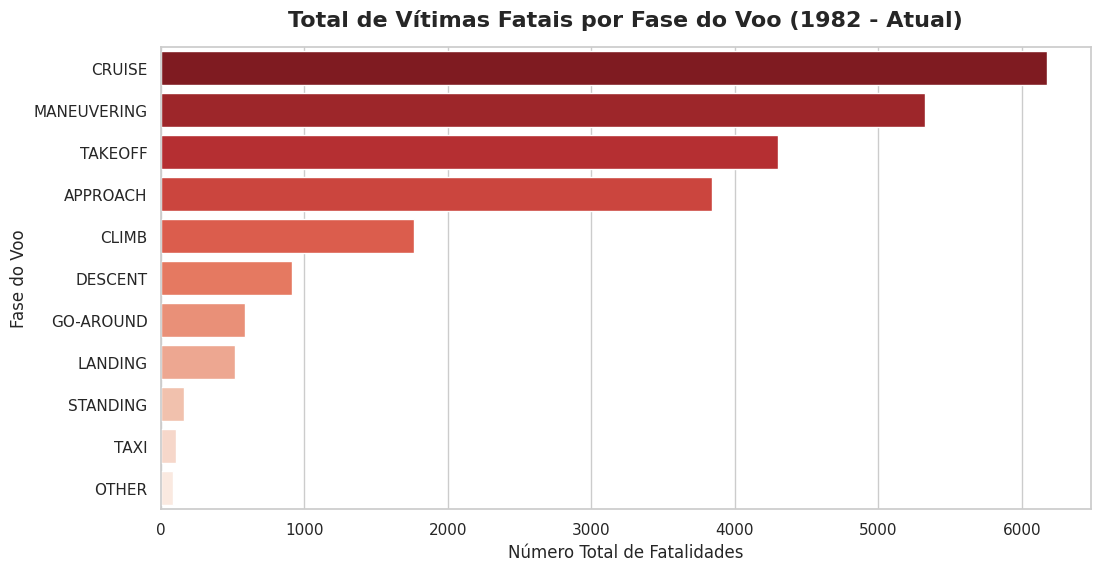

In [9]:
# Agrupar total de fatalidades por fase do voo
mortes_por_fase = df_clean.groupby('Broad.phase.of.flight')['Total.Fatal.Injuries'].sum().sort_values(ascending=False).reset_index()

# Criar o gráfico de barras horizontais
plt.figure(figsize=(12, 6))
sns.barplot(
    data=mortes_por_fase,
    x='Total.Fatal.Injuries',
    y='Broad.phase.of.flight',
    hue='Broad.phase.of.flight',
    palette='Reds_r',
    legend=False
)

# Estilização
plt.title('Total de Vítimas Fatais por Fase do Voo (1982 - Atual)', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Número Total de Fatalidades', fontsize=12)
plt.ylabel('Fase do Voo', fontsize=12)
plt.show()

**💡 Insight Investigativo: A Quebra do Senso Comum**

A hipótese inicial foi **completamente refutada** pelas evidências.
* **O Perigo Oculto:** Diferente do que o público geral imagina, as fases de aproximação e pouso (`LANDING`) possuem baixa letalidade. O **Cruzeiro (CRUISE)** e a fase de **Manobras (MANEUVERING)** lideram o número total de fatalidades absolutas.
* **Por que isso acontece?** Acidentes no pouso costumam ser saídas de pista em baixa velocidade, onde a grande maioria dos passageiros sobrevive. Em contrapartida, falhas estruturais, descompressão ou perda de controle durante a fase de cruzeiro (em alta altitude e velocidade) são eventos muito mais raros, porém catastróficos, onde a taxa de sobrevivência beira o zero.

## 🔍 2. Condições climáticas adversas são realmente o maior causador de acidentes?

**Hipótese Investigativa:** A crença popular dita que tempestades, neblina e ventos fortes (condições de voo por instrumentos - IMC) são os principais responsáveis pela queda de aeronaves. Vamos confrontar essa ideia verificando a proporção de acidentes que ocorrem em dias de céu limpo (voo visual - VMC) versus dias de clima adverso (IMC).

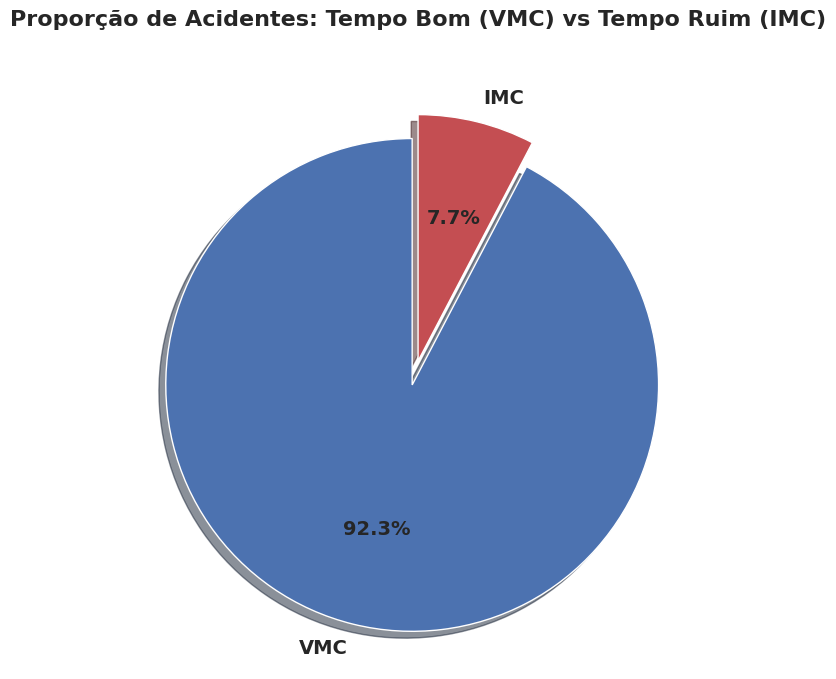

In [10]:
# Filtrar apenas os registros válidos de clima (VMC ou IMC)
df_clima = df_clean[df_clean['Weather.Condition'].isin(['VMC', 'IMC'])]

# Contar o número de acidentes por condição climática
contagem_clima = df_clima['Weather.Condition'].value_counts()

# Criar o gráfico de pizza
plt.figure(figsize=(8, 8))
cores = ['#4C72B0', '#C44E52'] # Azul para tempo bom, Vermelho para tempo ruim
explode = (0.1, 0) # Destacar a primeira fatia

plt.pie(
    contagem_clima,
    labels=contagem_clima.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=cores,
    explode=explode,
    shadow=True,
    textprops={'fontsize': 14, 'weight': 'bold'}
)

plt.title('Proporção de Acidentes: Tempo Bom (VMC) vs Tempo Ruim (IMC)', fontsize=16, fontweight='bold', pad=20)
plt.show()

**💡 Insight Investigativo: O Paradoxo do Clima**

Os dados revelam uma verdade chocante que contraria totalmente a intuição popular: **92.3% dos acidentes ocorrem em dias de céu limpo e tempo bom (VMC)**. Apenas 7.7% acontecem sob condições climáticas severas (IMC).
* **O Efeito Protocolo:** Em dias de tempestade ou baixa visibilidade, os pilotos seguem protocolos rigorosos de voo por instrumentos (IFR), dependem intensamente do controle de tráfego aéreo e operam com nível máximo de alerta.
* **O Fator Humano:** Em dias bonitos, ocorre o "excesso de confiança" e o relaxamento na cabine (complacência). A maioria esmagadora dessas quedas é resultado de falha humana, perda de controle visual ou pilotos inexperientes de pequenos aviões que tomam decisões ruins simplesmente porque "o tempo está bom". Na aviação, o clima severo não derruba aviões com a mesma frequência que a falha humana em dias claros.

## 🔍 3. Aviões construídos por amadores são mais letais quando caem?

**Hipótese Investigativa:** Aeronaves de construção amadora (`Amateur.Built = Yes`), por não passarem pelos mesmos testes de estresse de fábricas consagradas, possuem uma taxa de letalidade muito maior em caso de acidentes do que as aeronaves comerciais ou executivas (`Amateur.Built = No`).

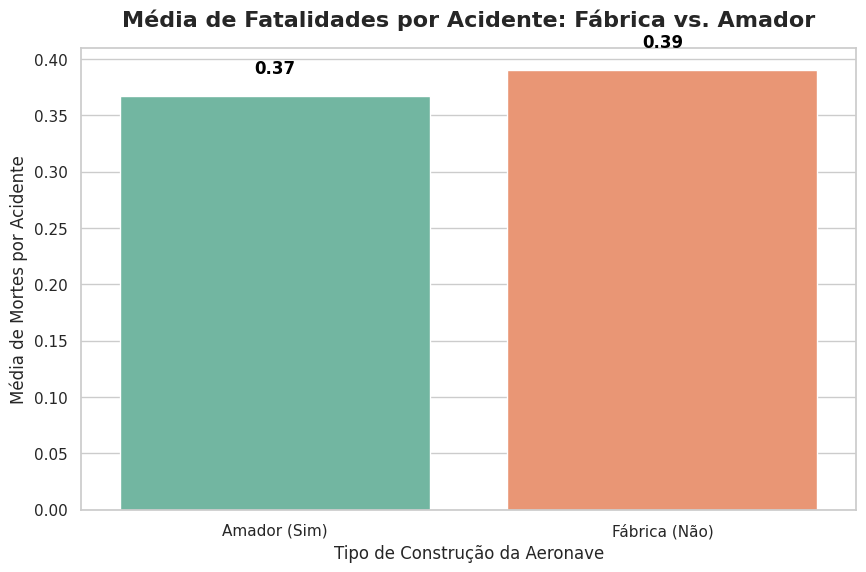

In [12]:
# Filtrar os registros corretos (agora buscando por YES e NO em maiúsculo)
df_amador = df_clean[df_clean['Amateur.Built'].isin(['YES', 'NO'])].copy()
df_amador['Amateur.Built'] = df_amador['Amateur.Built'].replace({'YES': 'Amador (Sim)', 'NO': 'Fábrica (Não)'})

# Agrupar a média de vítimas fatais por tipo de construção
media_mortes_amador = df_amador.groupby('Amateur.Built')['Total.Fatal.Injuries'].mean().reset_index()

# Criar o gráfico
plt.figure(figsize=(10, 6))
sns.barplot(
    data=media_mortes_amador,
    x='Amateur.Built',
    y='Total.Fatal.Injuries',
    hue='Amateur.Built',
    palette='Set2',
    legend=False
)

plt.title('Média de Fatalidades por Acidente: Fábrica vs. Amador', fontsize=16, fontweight='bold', pad=15)
plt.xlabel('Tipo de Construção da Aeronave', fontsize=12)
plt.ylabel('Média de Mortes por Acidente', fontsize=12)

# Adicionar os rótulos de dados em cima das barras para ficar profissional
for index, row in media_mortes_amador.iterrows():
    plt.text(index, row['Total.Fatal.Injuries'] + 0.02, f"{row['Total.Fatal.Injuries']:.2f}",
             color='black', ha="center", fontsize=12, fontweight='bold')

plt.show()

**💡 Insight Investigativo: A Ilusão das Médias e a Capacidade**

Ao contrário da hipótese inicial, as evidências apontam que acidentes com aeronaves de fábrica possuem uma média de fatalidades (0.39) levemente superior aos de construção amadora (0.37).
* **O Fator Capacidade:** Aviões amadores são majoritariamente monomotores experimentais de 1 a 2 assentos, limitando drasticamente o número máximo absoluto de vítimas fatais por evento.
* **O Peso dos Comerciais:** A categoria "Fábrica" engloba aeronaves comerciais e executivas de alta capacidade. Embora caiam com muito menos frequência graças aos rigorosos padrões de manutenção, os raros acidentes envolvendo essas aeronaves (especialmente na fase de cruzeiro, como visto no primeiro gráfico) resultam em perdas massivas de vidas, elevando a média estatística do grupo.

## 🧩 Análise Combinada: Interação entre Variáveis

**Objetivo:** Entender como múltiplas características do aplicativo interagem simultaneamente para influenciar sua avaliação e formato.



⏳ Baixando e preparando as evidências...
📊 Gerando Painel Investigativo...



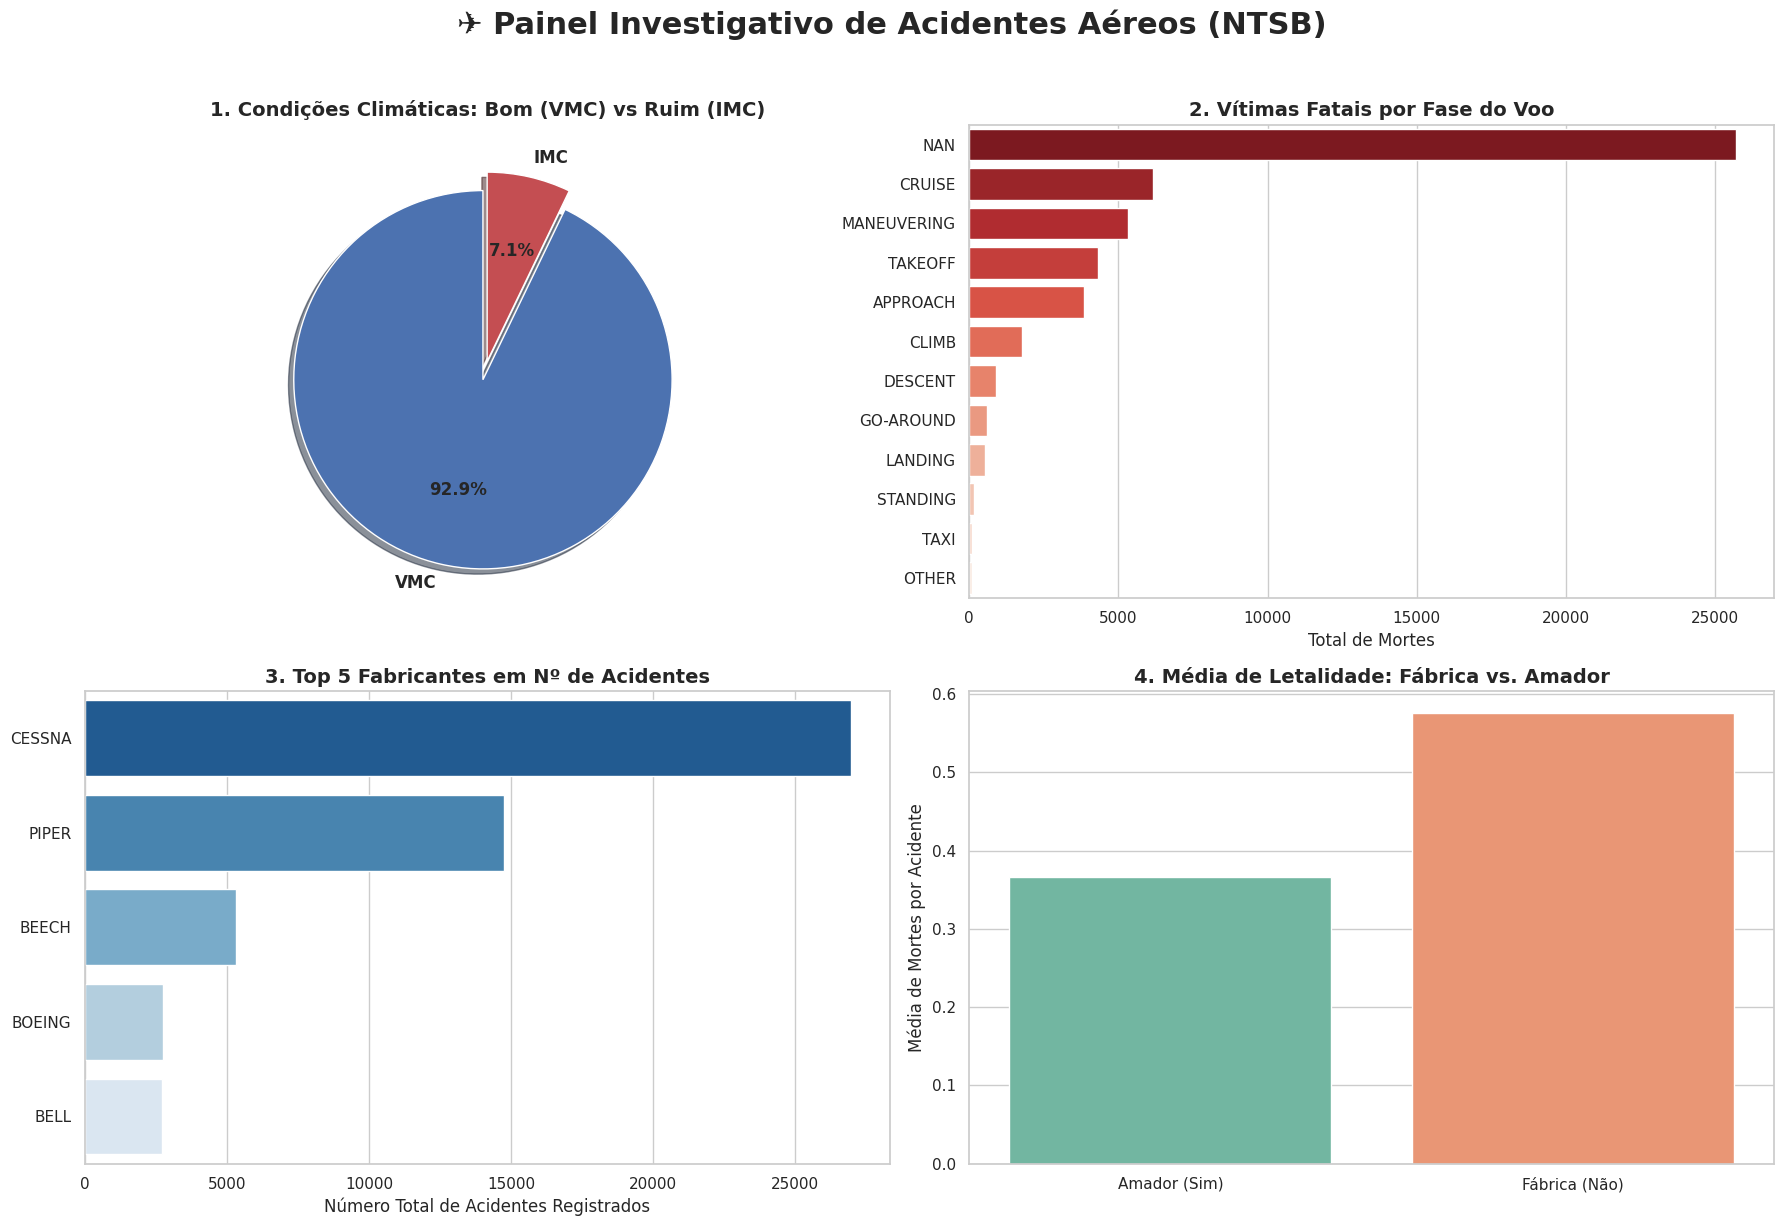

In [2]:
# ==============================================================================
# 🚀 PIPELINE COMPLETO: Download, Limpeza e Dashboard de Acidentes Aéreos (NTSB)
# ==============================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import gdown
import warnings
warnings.filterwarnings('ignore') # Oculta avisos visuais do Seaborn

# Configurações visuais padrão
sns.set_theme(style="whitegrid")

# ---------------------------------------------------------
# 1. DOWNLOAD E CARREGAMENTO DOS DADOS (Via Google Drive)
# ---------------------------------------------------------
print("⏳ Baixando e preparando as evidências...")
file_id = '1aEBisjagIdPejvb-yHI-CNZSdBrz665I'
url = f'https://drive.google.com/uc?id={file_id}'
output = 'AviationData.csv'
gdown.download(url, output, quiet=True)
df = pd.read_csv(output, encoding="latin-1", low_memory=False)

# ---------------------------------------------------------
# 2. LIMPEZA PERICIAL DOS DADOS
# ---------------------------------------------------------
colunas_inuteis = ['Schedule', 'Air.carrier', 'FAR.Description', 'Longitude', 'Latitude', 'Airport.Code', 'Airport.Name', 'Publication.Date']
df_clean = df.drop(columns=colunas_inuteis)

colunas_vitimas = ['Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured']
df_clean[colunas_vitimas] = df_clean[colunas_vitimas].fillna(0)

colunas_texto = ['Weather.Condition', 'Amateur.Built', 'Broad.phase.of.flight']
for col in colunas_texto:
    df_clean[col] = df_clean[col].astype(str).str.strip().str.upper()

df_clean = df_clean.dropna(subset=['Broad.phase.of.flight'])
df_clean['Broad.phase.of.flight'] = df_clean['Broad.phase.of.flight'].replace('UNKNOWN', np.nan)
df_clean = df_clean.dropna(subset=['Broad.phase.of.flight'])

# ---------------------------------------------------------
# 3. PAINEL DE ANÁLISE COMBINADA (DASHBOARD 2x2)
# ---------------------------------------------------------
print("📊 Gerando Painel Investigativo...\n")
fig, axs = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('✈️ Painel Investigativo de Acidentes Aéreos (NTSB)', fontsize=22, fontweight='bold', y=1.02)

# --- Gráfico 1: Proporção de Clima ---
df_clima = df_clean[df_clean['Weather.Condition'].isin(['VMC', 'IMC'])]
contagem_clima = df_clima['Weather.Condition'].value_counts()
axs[0, 0].pie(contagem_clima, labels=contagem_clima.index, autopct='%1.1f%%',
              startangle=90, colors=['#4C72B0', '#C44E52'], explode=(0.1, 0), shadow=True,
              textprops={'fontsize': 12, 'weight': 'bold'})
axs[0, 0].set_title('1. Condições Climáticas: Bom (VMC) vs Ruim (IMC)', fontsize=14, fontweight='bold')

# --- Gráfico 2: Fatalidades por Fase do Voo ---
mortes_por_fase = df_clean.groupby('Broad.phase.of.flight')['Total.Fatal.Injuries'].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=mortes_por_fase, x='Total.Fatal.Injuries', y='Broad.phase.of.flight',
            palette='Reds_r', ax=axs[0, 1], hue='Broad.phase.of.flight', legend=False)
axs[0, 1].set_title('2. Vítimas Fatais por Fase do Voo', fontsize=14, fontweight='bold')
axs[0, 1].set_xlabel('Total de Mortes')
axs[0, 1].set_ylabel('')

# --- Gráfico 3: Top 5 Fabricantes ---
df_clean['Make'] = df_clean['Make'].astype(str).str.upper().str.strip()
top_makes = df_clean['Make'].value_counts().head(5).reset_index()
sns.barplot(data=top_makes, x='count', y='Make', palette='Blues_r', ax=axs[1, 0], hue='Make', legend=False)
axs[1, 0].set_title('3. Top 5 Fabricantes em Nº de Acidentes', fontsize=14, fontweight='bold')
axs[1, 0].set_xlabel('Número Total de Acidentes Registrados')
axs[1, 0].set_ylabel('')

# --- Gráfico 4: Média de Mortes - Amador vs Fábrica ---
df_amador = df_clean[df_clean['Amateur.Built'].isin(['YES', 'NO'])].copy()
df_amador['Amateur.Built'] = df_amador['Amateur.Built'].replace({'YES': 'Amador (Sim)', 'NO': 'Fábrica (Não)'})
media_mortes_amador = df_amador.groupby('Amateur.Built')['Total.Fatal.Injuries'].mean().reset_index()
sns.barplot(data=media_mortes_amador, x='Amateur.Built', y='Total.Fatal.Injuries',
            palette='Set2', ax=axs[1, 1], hue='Amateur.Built', legend=False)
axs[1, 1].set_title('4. Média de Letalidade: Fábrica vs. Amador', fontsize=14, fontweight='bold')
axs[1, 1].set_xlabel('')
axs[1, 1].set_ylabel('Média de Mortes por Acidente')

# Ajuste de layout
plt.tight_layout()
plt.show()

### 💡 Insights da Análise Combinada:
* **Gráfico 1 (O Paradoxo do Clima):** Contra a intuição popular, 92.3% dos acidentes ocorrem em céu claro e tempo bom (VMC). A complacência do fator humano supera o risco do clima adverso.
* **Gráfico 2 (Perigo em Altitude):** A fase de cruzeiro e manobras lideram as fatalidades absolutas. Fases temidas, como o pouso, possuem alta taxa de sobrevivência, resultando em menos fatalidades totais.
* **Gráfico 3 (Volume de Frota):** Cessna e Piper lideram as estatísticas. Isso não indica falha de engenharia, mas sim a dominância absoluta dessas marcas na aviação geral e de instrução (onde ocorrem mais incidentes de baixo impacto).
* **Gráfico 4 (A Ilusão da Média):** Aeronaves de fábrica possuem uma letalidade média levemente maior (0.39) que aeronaves amadoras. Isso ocorre porque a categoria "Fábrica" engloba jatos comerciais massivos; um único acidente comercial puxa a média estatística para cima, superando os acidentes frequentes, porém solitários, de monomotores amadores.